# **Amsterdam Listings Price Prediction from Images**

## Setup

In [2]:
import pandas as pd
import numpy as np
import os
import requests
from PIL import Image
from io import BytesIO
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


2025-07-13 07:37:15.439389: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752392235.628505      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752392235.681988      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## GPU stuff

In [3]:
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
tf.config.list_physical_devices('GPU')

TensorFlow version: 2.18.0
Num GPUs Available: 1


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

## Load Training Dataset

In [4]:
train_df = pd.read_csv("/kaggle/input/listings/train_listings.csv")
train_df['price'] = (
    train_df['price'].astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)
    .astype(float)
)
train_df = train_df[(train_df['price'] >= 50) & (train_df['price'] <= 2000)]
train_df['log_price'] = np.log1p(train_df['price'])  # Optional: log price


In [5]:
IMAGE_SIZE = (224, 224)
def download_and_preprocess(url):
    try:
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img = img.resize(IMAGE_SIZE)
        img_array = img_to_array(img)
        return preprocess_input(img_array)
    except:
        return None

# Only use rows with valid image URLs
train_df = train_df[train_df['picture_url'].notnull()]
tqdm.pandas()
train_df['image_array'] = train_df['picture_url'].progress_apply(download_and_preprocess)
train_df = train_df[train_df['image_array'].notnull()]


  5%|▌         | 272/5024 [02:10<36:34,  2.17it/s]  /usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (149970000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
  6%|▌         | 284/5024 [02:20<55:38,  1.42it/s]  /usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (96850215 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
 89%|████████▊ | 4453/5024 [36:26<04:34,  2.08it/s] /usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (99532800 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
100%|██████████| 5024/5024 [41:13<00:00,  2.03it/s]


In [6]:
# Save the images
np.save("/kaggle/working/all_images.npy", np.stack(train_df['image_array'].values))

In [8]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

## Trying Resnet with ImageNet

In [12]:
resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224,224,3))

image_stack = np.stack(train_df['image_array'].values)
features = resnet.predict(image_stack, batch_size=32)


I0000 00:00:1752394997.290651      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1752395013.305265     109 service.cc:148] XLA service 0x7e948014aef0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752395013.306184     109 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1752395013.917920     109 cuda_dnn.cc:529] Loaded cuDNN version 90300


  4/157 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step

I0000 00:00:1752395017.042516     109 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step


In [13]:
X = features
y = train_df['log_price'].values  # or 'price' if not log-transformed

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=32)


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 4.1628 - val_loss: 2.2270
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5196 - val_loss: 2.8143
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3645 - val_loss: 1.3382
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2880 - val_loss: 2.1923
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2188 - val_loss: 1.9471
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0031 - val_loss: 1.6829
Epoch 7/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9331 - val_loss: 2.1498
Epoch 8/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0234 - val_loss: 2.3854
Epoch 9/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9326 - val_loss: 1.6118
Epoch 10/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8918 - val_loss: 2.3441
Epoch 11/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9080 - val_loss: 1.9175
Epoch 12/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0

In [14]:
log_preds = model.predict(X_val).flatten()
actual_prices = np.expm1(y_val)
predicted_prices = np.expm1(log_preds)

mae = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
r2 = r2_score(actual_prices, predicted_prices)

print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R² Score: {r2:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MAE: $184.93
RMSE: $249.24
R² Score: -1.1078


In [15]:
base = ResNet50(
    weights="imagenet",        # ← ready‑made in TF/Keras
    include_top=False,         # drop the 1000‑way classifier
    pooling="avg",             # global‑average‑pool to 2048‑D vector
    input_shape=(224, 224, 3),
)
base.trainable = False         # freeze for the first phase

In [17]:
from tensorflow.keras import Sequential, layers, optimizers, losses, metrics

model = Sequential(
    [
        base,
        layers.Dropout(0.2),
        layers.Dense(1, activation="linear"),   # ← regression head
    ]
)

model.compile(
    optimizer=optimizers.Adam(0.001),
    loss=losses.MeanSquaredError(),
    metrics=[metrics.RootMeanSquaredError(name="rmse"), "mae"],
)

In [18]:
X = np.stack(train_df["image_array"].values).astype("float32")
y = train_df["log_price"].values        # you already log‑transformed 💡

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42
)

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
    .shuffle(1024)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

In [20]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_rmse", patience=5, restore_best_weights=True)
]

# Phase 1 – train only the 1‑unit regressor
history_1 = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

# Phase 2 – unfreeze last 2‑3 ResNet blocks for fine‑tuning
base.trainable = True
for layer in base.layers[:-20]:      # keep majority frozen
    layer.trainable = False

model.compile(                       # lower LR for fine‑tuning!
    optimizer=optimizers.Adam(1e-4),
    loss=losses.MeanSquaredError(),
    metrics=[metrics.RootMeanSquaredError(name="rmse"), "mae"],
)

history_2 = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

Epoch 1/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 33s 139ms/step - loss: 5.3969 - mae: 1.7061 - rmse: 2.1833 - val_loss: 0.6390 - val_mae: 0.6349 - val_rmse: 0.7994
Epoch 2/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - loss: 0.9553 - mae: 0.7748 - rmse: 0.9772 - val_loss: 0.5792 - val_mae: 0.5961 - val_rmse: 0.7611
Epoch 3/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 0.7796 - mae: 0.6967 - rmse: 0.8826 - val_loss: 0.4501 - val_mae: 0.5272 - val_rmse: 0.6709
Epoch 4/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 0.6390 - mae: 0.6276 - rmse: 0.7992 - val_loss: 0.4356 - val_mae: 0.5144 - val_rmse: 0.6600
Epoch 5/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - loss: 0.5505 - mae: 0.5860 - rmse: 0.7418 - val_loss: 0.3908 - val_mae: 0.4940 - val_rmse: 0.6252
Epoch 6/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 0.4946 - mae: 0.5577 - rmse: 0.7032 - val_loss: 0.3787 - val_mae: 0.4890 - val_rmse: 0.6154
Epoch 7/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 0.4483 - mae: 0.531

In [22]:
pred_log = model.predict(val_ds).ravel()
pred_price = np.expm1(pred_log)       # inverse of log1p
true_price = np.expm1(y_val)

# print("MAE ($):", mean_absolute_error(true_price, pred_price))

mae = mean_absolute_error(true_price, pred_price)
rmse = np.sqrt(mean_squared_error(true_price, pred_price))
r2 = r2_score(true_price, pred_price)

print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R² Score: {r2:.4f}")


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
MAE: $103.52
RMSE: $177.50
R² Score: -0.0496


### Why do images alone seem to struggle to predict Airbnb price?

- Location: not visible
- Demand: not visible
- Amenities: partially visible
- Listings of capacity (beds, bathrooms): not visible
- Host strategy (dynamic pricing, cleaning fees): not visible
- Photo quality: visible

Only 1 signal explains why there is a poor r2 score!

## Hybrid model (by also using tabular features)

In [47]:
import numpy as np
import pandas as pd
from PIL import Image
from io import BytesIO
import requests
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, Concatenate, Input, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.losses import Huber
from keras.callbacks import ReduceLROnPlateau
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Define paths
IMAGE_SAVE_PATH = "/kaggle/working/preprocessed_images.npy"
INDICES_SAVE_PATH = "/kaggle/working/image_indices.npy"
IMAGE_SIZE = (224, 224)

def download_and_preprocess(url):
    try:
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img = img.resize(IMAGE_SIZE)
        img_array = img_to_array(img)
        return preprocess_input(img_array)
    except:
        return None

def save_preprocessed_images(df, image_path=IMAGE_SAVE_PATH, indices_path=INDICES_SAVE_PATH):
    """Save preprocessed images and their indices"""
    # Save the image arrays
    np.save(image_path, np.stack(df['image_array'].values))
    # Save the corresponding DataFrame indices
    np.save(indices_path, df.index.values)
    print(f"Saved {len(df)} preprocessed images")

def load_preprocessed_images(df, image_path=IMAGE_SAVE_PATH, indices_path=INDICES_SAVE_PATH):
    """Load preprocessed images and match them with the DataFrame"""
    # Load images and indices
    image_arrays = np.load(image_path)
    saved_indices = np.load(indices_path)
    
    # Create a dictionary mapping indices to image arrays
    image_dict = dict(zip(saved_indices, image_arrays))
    
    # Create new column by mapping current indices to saved images
    df['image_array'] = df.index.map(image_dict)
    
    # Filter rows where image loading was successful
    df = df[df['image_array'].notnull()]
    print(f"Loaded {len(df)} preprocessed images")
    return df



Loading preprocessed images from disk
Loaded 5020 preprocessed images


### Load training data

In [ ]:
# Load data
train_df = pd.read_csv("/kaggle/input/listings/train_listings.csv")

# Preprocess prices
train_df['price'] = (
    train_df['price'].astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)
    .astype(float)
)
train_df = train_df[(train_df['price'] >= 50) & (train_df['price'] <= 2000)]
train_df['log_price'] = np.log1p(train_df['price'])

# Handle images - either download or load saved
if Path(IMAGE_SAVE_PATH).exists():
    print("Loading preprocessed images from disk")
    train_df = train_df[train_df['picture_url'].notnull()]
    train_df = load_preprocessed_images(train_df)
else:
    print("Downloading and preprocessing images")
    train_df = train_df[train_df['picture_url'].notnull()]
    tqdm.pandas()
    train_df['image_array'] = train_df['picture_url'].progress_apply(download_and_preprocess)
    train_df = train_df[train_df['image_array'].notnull()]
    save_preprocessed_images(train_df)

image_arrays = np.stack(train_df['image_array'].values)

### Load testing data

In [22]:
# === Constants for test set ===
TEST_IMAGE_SAVE_PATH = "/kaggle/working/test_preprocessed_images.npy"
TEST_INDICES_SAVE_PATH = "/kaggle/working/test_image_indices.npy"
IMAGE_SIZE = (224, 224)

def save_preprocessed_images_test(df, image_path=TEST_IMAGE_SAVE_PATH, indices_path=TEST_INDICES_SAVE_PATH):
    """Save preprocessed test images and their indices"""
    np.save(image_path, np.stack(df['image_array'].values))
    np.save(indices_path, df.index.values)
    print(f"Saved {len(df)} preprocessed test images")

def load_preprocessed_images_test(df, image_path=TEST_IMAGE_SAVE_PATH, indices_path=TEST_INDICES_SAVE_PATH):
    """Load preprocessed test images and match with test DataFrame"""
    image_arrays = np.load(image_path)
    saved_indices = np.load(indices_path)
    image_dict = dict(zip(saved_indices, image_arrays))
    df['image_array'] = df.index.map(image_dict)
    df = df[df['image_array'].notnull()]
    print(f"Loaded {len(df)} preprocessed test images")
    return df

# === Load test data ===
test_df = pd.read_csv("/kaggle/input/listings/test_listings.csv")

# Preprocess price column if needed (depends on your task)
test_df['price'] = (
    test_df['price'].astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)
    .astype(float)
)
test_df = test_df[(test_df['price'] >= 50) & (test_df['price'] <= 2000)]
test_df['log_price'] = np.log1p(test_df['price'])

# Handle test images
if Path(TEST_IMAGE_SAVE_PATH).exists():
    print("Loading preprocessed test images from disk")
    test_df = test_df[test_df['picture_url'].notnull()]
    test_df = load_preprocessed_images_test(test_df)
else:
    print("Downloading and preprocessing test images")
    test_df = test_df[test_df['picture_url'].notnull()]
    tqdm.pandas()
    test_df['image_array'] = test_df['picture_url'].progress_apply(download_and_preprocess)
    test_df = test_df[test_df['image_array'].notnull()]
    save_preprocessed_images_test(test_df)

# Final image array
test_image_arrays = np.stack(test_df['image_array'].values)

100%|██████████| 1257/1257 [08:15<00:00,  2.54it/s]


Saved 1257 preprocessed test images


In [26]:
# Reset index after filtering
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Select relevant tabular features
tabular_features = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',  # Property characteristics
    'minimum_nights', 'maximum_nights',  # Booking rules
    'number_of_reviews', 'review_scores_rating',  # Popularity and reviews
    'latitude', 'longitude',  # Location
    'property_type', 'room_type',  # Categorical features
    'host_is_superhost', 'instant_bookable'  # Host and booking features
]

In [31]:
# Preprocess tabular data
X = train_df[tabular_features]
y = train_df['log_price']  # Using log price as target

X_test = test_df[tabular_features]
y_test = test_df['log_price']

In [5]:
# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Define preprocessing for numerical and categorical features
numeric_features = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 
                   'minimum_nights', 'maximum_nights', 'number_of_reviews',
                   'review_scores_rating', 'latitude', 'longitude']
numeric_transformer = StandardScaler()

categorical_features = ['property_type', 'room_type', 'host_is_superhost', 'instant_bookable']
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [34]:
# Get the indices used for train/val split
train_indices = X_train.index
val_indices = X_val.index

# and test
test_indices = X_test.index

# Load the preprocessed images
image_arrays = np.stack(train_df['image_array'].values)

# Select images using the correct indices
X_train_images = image_arrays[train_indices]
X_val_images = image_arrays[val_indices]
X_test_images = test_image_arrays[test_indices]

In [10]:
# Get the shape of processed tabular data
tabular_input_shape = X_train_processed.shape[1]

# just in case...
test_tabular_input_shape = X_test_processed.shape[1]

In [35]:
# Handle missing values in numeric features
numeric_imputer = SimpleImputer(strategy='median')
X_train[numeric_features] = numeric_imputer.fit_transform(X_train[numeric_features])
X_val[numeric_features] = numeric_imputer.transform(X_val[numeric_features])
X_test[numeric_features] = numeric_imputer.transform(X_test[numeric_features])

# Update the preprocessor to handle missing values
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [37]:
# Process the data
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_val_processed = X_val_processed.toarray()
    X_test_processed = X_test_processed.toarray()

In [43]:
# Enhanced model architecture
def create_improved_model(tabular_input_shape):
    # Image branch
    image_input = Input(shape=(224, 224, 3))
    base_model = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')
    base_model.trainable = False  # Start with frozen, consider unfreezing later
    x = base_model(image_input)
    x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    # Tabular branch
    tab_input = Input(shape=(tabular_input_shape,))
    y = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(tab_input)
    y = BatchNormalization()(y)
    y = Dropout(0.3)(y)
    y = Dense(64, activation='relu')(y)
    
    # Combined
    combined = Concatenate()([x, y])
    z = Dense(64, activation='relu')(combined)
    z = BatchNormalization()(z)
    z = Dropout(0.2)(z)
    z = Dense(32, activation='relu')(z)
    output = Dense(1)(z)
    
    model = Model(inputs=[image_input, tab_input], outputs=output)
    
    optimizer = Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, 
                 loss=huber_loss,
                 metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse"),
                          tf.keras.metrics.MeanAbsoluteError(name="mae")])
    return model

# Create model
model = create_multi_modal_model(X_train_processed.shape[1])

In [44]:
# Add early stopping
early_stopping = EarlyStopping(
    monitor='val_mae',
    patience=5,
    restore_best_weights=True,
    mode='min',  # Explicitly looking for a lower val_mae
    verbose=1     # Helpful to log when early stopping triggers
)

In [48]:
# Optionally add Reduce LR when learning plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=3,
    verbose=1,
    mode='min',
    min_lr=1e-6
)

In [49]:
# Add early stopping
# early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

# Train with validation
history = model.fit(
    [X_train_images, X_train_processed], y_train,
    validation_data=([X_val_images, X_val_processed], y_val),
    epochs=50,  # More epochs with early stopping
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 136s 413ms/step - loss: 27.9736 - mae: 5.0960 - val_loss: 15.5062 - val_mae: 3.8603 - learning_rate: 0.0010
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 119ms/step - loss: 12.2640 - mae: 3.2536 - val_loss: 2.5250 - val_mae: 1.4077 - learning_rate: 0.0010
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - loss: 2.8444 - mae: 1.3361 - val_loss: 1.0661 - val_mae: 0.7262 - learning_rate: 0.0010
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 119ms/step - loss: 1.8170 - mae: 1.0237 - val_loss: 0.2747 - val_mae: 0.4041 - learning_rate: 0.0010
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - loss: 1.4387 - mae: 0.9278 - val_loss: 1.0240 - val_mae: 0.6929 - learning_rate: 0.0010
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 119ms/step - loss: 1.2815 - mae: 0.8533 - val_loss: 0.2354 - val_mae: 0.3694 - learning_rate: 0.0010
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 119ms/step - loss: 1.1113 - mae: 0.7943 - val_loss: 0.2336 - val_mae: 0.3498 - lea

In [50]:
# Evaluate the model
val_loss, val_mae = model.evaluate([X_val_images, X_val_processed], y_val)
print(f"Validation MAE: {val_mae:.4f} (in log price space)")
print(f"Approximate MAE in original price space: ${np.expm1(val_mae):.2f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1089 - mae: 0.2502
Validation MAE: 0.2541 (in log price space)
Approximate MAE in original price space: $0.29


126/126 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step

Training Set Metrics:
R² Score: 0.5979
MAE: $73.11
RMSE: $144.25
MAPE: 24.59%
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step

Validation Set Metrics:
R² Score: 0.5624
MAE: $70.47
RMSE: $128.90
MAPE: 25.05%
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


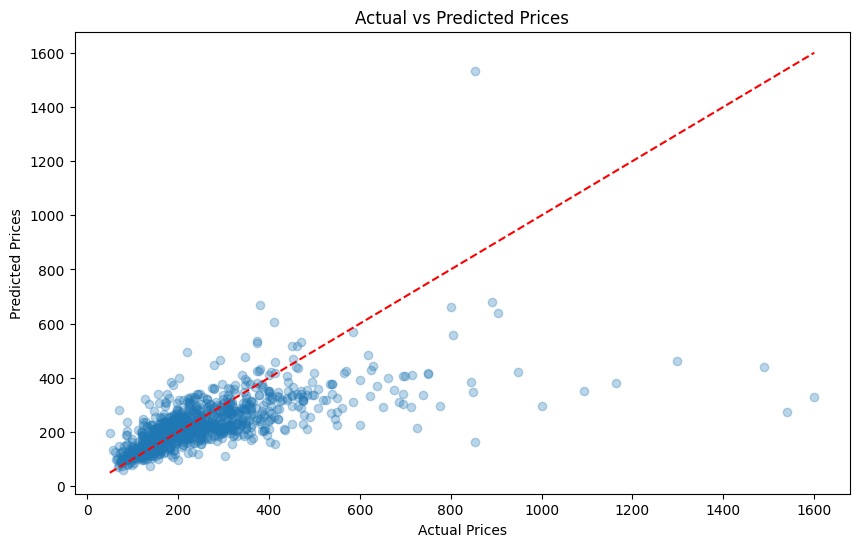

In [51]:
def evaluate_model(model, X_images, X_tabular, y_true, set_name="Validation"):
    """Calculate and print evaluation metrics"""
    # Get predictions
    y_pred = model.predict([X_images, X_tabular]).flatten()
    
    # Convert from log price to actual price
    y_true_actual = np.expm1(y_true)
    y_pred_actual = np.expm1(y_pred)
    
    # Calculate metrics
    metrics = {
        'r2': r2_score(y_true, y_pred),
        'mae': mean_absolute_error(y_true_actual, y_pred_actual),
        'rmse': np.sqrt(mean_squared_error(y_true_actual, y_pred_actual)),
        'mape': np.mean(np.abs((y_true_actual - y_pred_actual) / y_true_actual)) * 100
    }
    
    # Print results
    print(f"\n{set_name} Set Metrics:")
    print(f"R² Score: {metrics['r2']:.4f}")
    print(f"MAE: ${metrics['mae']:.2f}")
    print(f"RMSE: ${metrics['rmse']:.2f}")
    print(f"MAPE: {metrics['mape']:.2f}%")
    
    return metrics

# Evaluate on both training and validation sets
train_metrics = evaluate_model(
    model, 
    X_train_images, 
    X_train_processed, 
    y_train, 
    "Training"
)

val_metrics = evaluate_model(
    model, 
    X_val_images, 
    X_val_processed, 
    y_val, 
    "Validation"
)

# Additional visualization
import matplotlib.pyplot as plt

def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.3)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.title(title)
    plt.show()

# Get validation predictions for plotting
val_preds = model.predict([X_val_images, X_val_processed]).flatten()
val_actuals = np.expm1(y_val)
val_preds_actual = np.expm1(val_preds)

plot_predictions(val_actuals, val_preds_actual, "Actual vs Predicted Prices")

## Test set evaluation

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step

Test Set Metrics:
R² Score: 0.5501
MAE: $69.04
RMSE: $126.74
MAPE: 26.11%
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


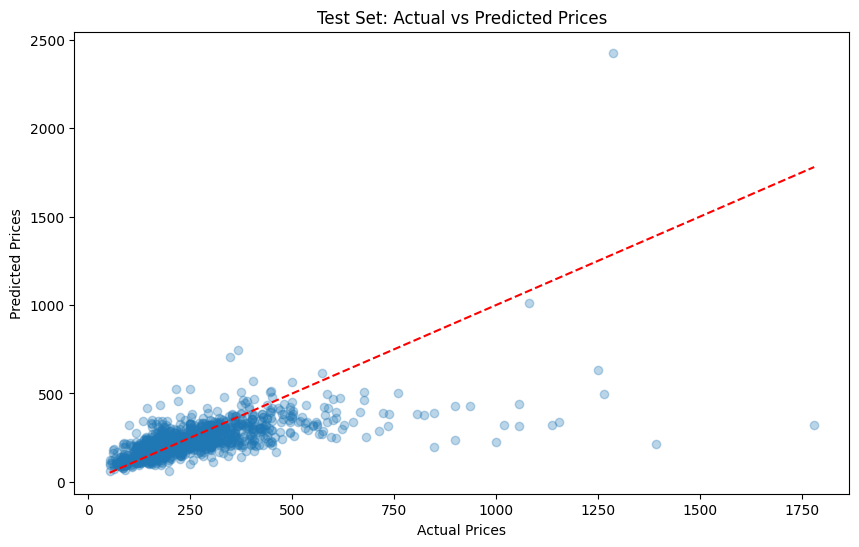

In [52]:
test_metrics = evaluate_model(
    model, 
    X_test_images, 
    X_test_processed, 
    y_test, 
    "Test"
)

test_preds = model.predict([X_test_images, X_test_processed]).flatten()
test_actuals = np.expm1(y_test_log)
test_preds_actual = np.expm1(test_preds)

plot_predictions(test_actuals, test_preds_actual, "Test Set: Actual vs Predicted Prices")
